In [25]:
import ROOT

import numpy as np

from tqdm import tqdm

b = { "1" : 0.000136452,
      "2" : -0.00384747,
      "3" : 0.00810865,
      "4" : 0.001944,
      "5" : 0.00163575,
      "6" : 0.0013271
      }

c = { "1" : 1.9818,
      "2" : 2.10489,
      "3" : 2.07277,
      "4" : 1.84785,
      "5" : 2.25603,
      "6" : 1.9558
      }

def get_resolution( energy, key ):
    return ( b[key] + c[key] / np.sqrt( energy ) ) * energy

In [26]:
f1 = ROOT.TFile("/data0/biasissi/sim/rootfiles/19F_pg_1.root")
t1 = f1.Get("Tree1")

data = {"BGO1": [], "BGO2": [], "BGO3": [], "BGO4": [], "BGO5": [], "BGO6": [] }
n_entries = t1.GetEntries()

for i in tqdm(range(n_entries)):
    t1.GetEntry(i)
    energies = t1.Edep
    for j in range(6):
        if energies[j] > 0:
            reso = get_resolution( energies[j], str(j+1) )
            energy = np.random.normal( energies[j], reso )
            data["BGO" + str(j+1)].append( energy )
        else:
            data["BGO" + str(j+1)].append( 0 )


100%|██████████| 1000000/1000000 [00:13<00:00, 74108.60it/s]


In [27]:
# List all files within /data0/biasissi/sim/rootfiles/ directory
import os
files = os.listdir("/data0/biasissi/sim/rootfiles/")

# Print files in alphabetical order
files.sort()
for file in files:
    print(file)

.DS_Store
11B_pg_0.root
11B_pg_1.root
12C_pg.root
19F_pag_1.root
19F_pag_2.root
19F_pag_2_Far.root
19F_pag_3.root
19F_pag_3_Far.root
19F_pag_4.root
19F_pag_4_Far.root
19F_pg_0.root
19F_pg_1.root
19F_pg_10.root
19F_pg_2.root
19F_pg_3.root
19F_pg_4.root
19F_pg_5.root
19F_pg_6.root
19F_pg_7.root
19F_pg_8.root
19F_pg_9.root


In [28]:
# Create BGOsum
bgo_sum = []
for i in range(len(data["BGO1"])):
    bgo_sum.append( data["BGO1"][i] + data["BGO2"][i] + data["BGO3"][i] + data["BGO4"][i] + data["BGO5"][i] + data["BGO6"][i] )

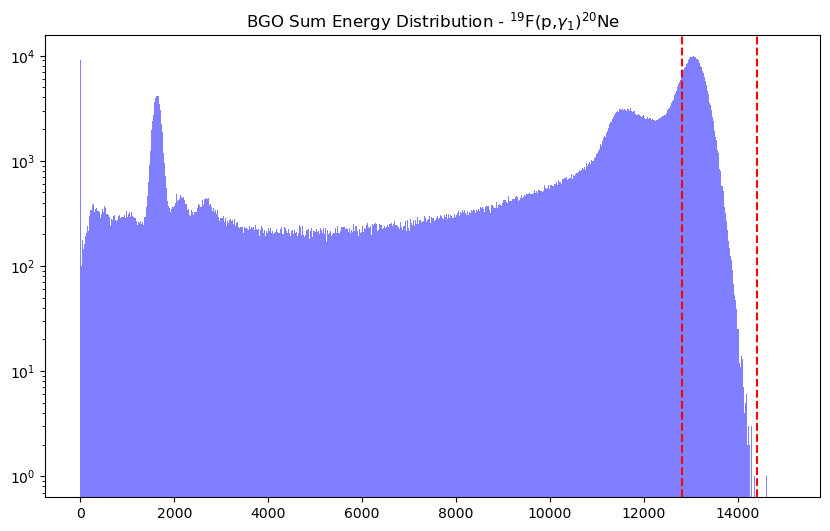

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(bgo_sum, bins=1000, range=(0, 15000), alpha=0.5, label='BGO Sum', color='blue')

plt.axvline(x=12800, color='red', linestyle='--', label='Zero Line')
plt.axvline(x=14400, color='red', linestyle='--', label='Threshold Line')

plt.title(r'BGO Sum Energy Distribution - $^{19}$F(p,$\gamma _{1}$)$^{20}$Ne')

plt.yscale('log')

plt.show()

In [30]:
# Get the mask of all the events in ROI
bgo_sum = np.array(bgo_sum)
mask = np.logical_and(bgo_sum > 12800, bgo_sum < 14400)

In [31]:
data["BGO1"] = np.array(data["BGO1"])[mask]
data["BGO2"] = np.array(data["BGO2"])[mask]
data["BGO3"] = np.array(data["BGO3"])[mask]
data["BGO4"] = np.array(data["BGO4"])[mask]
data["BGO5"] = np.array(data["BGO5"])[mask]
data["BGO6"] = np.array(data["BGO6"])[mask]

Bin number for x = 1350: 90
Bin number for x = 1930: 129
Number of events in the ROI: 236128
Background in the ROI: 47092.5
129 90 1350.91 1935.871
Counts in the ROI: 189035.5
856671 1000000
Efficiency: 0.1890355


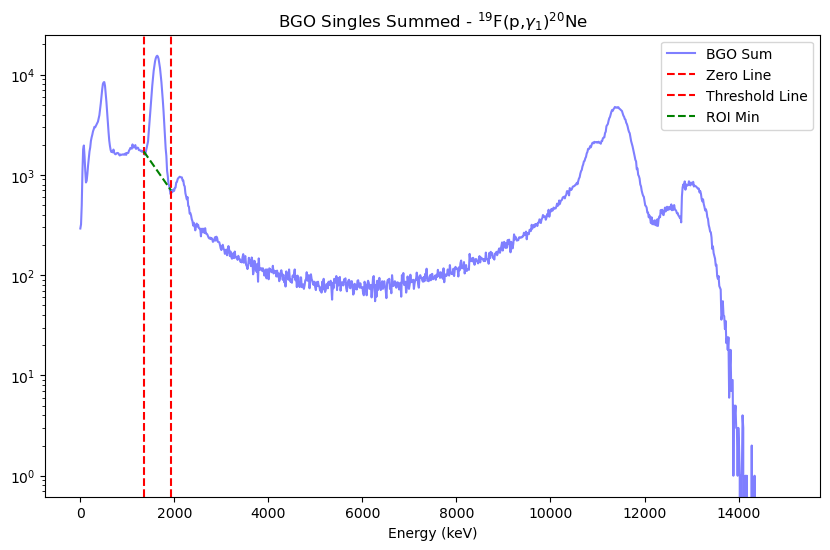

In [32]:
bins_1, edges = np.histogram(data["BGO1"], bins=1000, range=(1, 15000))
bins_2, edges = np.histogram(data["BGO2"], bins=1000, range=(1, 15000))
bins_3, edges = np.histogram(data["BGO3"], bins=1000, range=(1, 15000))
bins_4, edges = np.histogram(data["BGO4"], bins=1000, range=(1, 15000))
bins_5, edges = np.histogram(data["BGO5"], bins=1000, range=(1, 15000))
bins_6, edges = np.histogram(data["BGO6"], bins=1000, range=(1, 15000))

bins = bins_1 + bins_2 + bins_3 + bins_4 + bins_5 + bins_6

# Get the bin number for x = 1350 and x = 1930
bin_1350 = np.digitize(1350, edges)
# bin_1930 = np.digitize(1930, edges)
bin_1930 = np.digitize(1930, edges)
print("Bin number for x = 1350:", bin_1350)
print("Bin number for x = 1930:", bin_1930)

# Calculate the bkg_min and bkg_max
bkg_min = bins[bin_1350 - 1]
bkg_max = bins[bin_1930 + 1]

# Calculate number of events in the ROI by integrating the histogram
n_roi = np.sum(bins[bin_1350:bin_1930])
print("Number of events in the ROI:", n_roi)

# Calculate the background with trapezoid method
bkg = (bin_1930 - bin_1350) * (bkg_min + bkg_max) / 2
print("Background in the ROI:", bkg)
print( bin_1930, bin_1350, edges[bin_1350], edges[bin_1930] )

# Calculate the number of events in the ROI
counts = n_roi - bkg
print("Counts in the ROI:", counts)

print(np.sum(bins), n_entries)

print("Efficiency:", counts / n_entries)

plt.figure(figsize=(10, 6))

plt.plot(edges[:-1], bins, color='blue', label='BGO Sum', alpha=0.5)
plt.axvline(x=1350, color='red', linestyle='--', label='Zero Line')
plt.axvline(x=1930, color='red', linestyle='--', label='Threshold Line')

plt.plot([1350, 1930], [bkg_min, bkg_max], color='green', linestyle='--', label='ROI Min')

plt.title(r'BGO Singles Summed - $^{19}$F(p,$\gamma _{1}$)$^{20}$Ne')

plt.yscale('log')
plt.xlabel('Energy (keV)')

plt.legend()
plt.show()